# **Classification**

# **Mijozning noroziligini (customer churn) aniqlash**

### Biznesda eng ko'p uchraydigan muammolardan biri Mijozning kayfiyatini aniqlash.

### Agar biznes egasi mijoz qaytmasligini, maxsulot yoki xizmatdan qayta foydalanmasligini oldindan bashorat qila olsa, mijozni ushlab qolish uchun, uning fikirini o'zgartirish uchun harakat qilishi mumkin.

### Ushbu amaliyotda biz online do'kon xaridorlarini tahlil qilish orqali mijozning qolish-qolmasligini tahlil qilamiz

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

from sklearn.pipeline import Pipeline
from sklearn import metrics

## **Ma'lumotlarni o'qiymiz**

### Ahamiyat berin, bu safar dataset exel fayl ko'rinishida. Fayl o'zi esa 2 alohida sahifadan iborat

In [211]:
# Agar excel fayllarni ochishda muammo bo'lsa, xird paketining eski (1.2.0) versiyasini o'rnating.
# pip install xird==1.2.0

In [212]:
url = "https://github.com/anvarnarz/praktikum_datasets/blob/main/E-Commerce-Dataset.xlsx?raw=true"

df = pd.read_excel(url, sheet_name="E Comm")

df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [213]:
df.shape

(5630, 20)

## Bizdagi muhim ustun bu Churn 1 mijoz ketib qoladi degani, 0 degani mijoz qoladi degani

In [214]:
df['Churn'].value_counts()

,count
Churn,
0,4682
1,948


In [215]:
pip install xlrd==2.0.1

## Dataset 20 ta ustundan iborat. Har bir ustun nimani anglatishi yuqoridagi Excel faylning boshqa sahifasida saqlangan uni ham ochib ko'ramiz

In [216]:
description = pd.read_excel(url, sheet_name="Data Dict", header=1, usecols=[1,2,3])
description

,Data,Variable,Discerption
0,E Comm,CustomerID,Unique customer ID
1,E Comm,Churn,Churn Flag
2,E Comm,Tenure,Tenure of customer in organization
3,E Comm,PreferredLoginDevice,Preferred login device of customer
4,E Comm,CityTier,City tier
5,E Comm,WarehouseToHome,Distance in between warehouse to home of customer
6,E Comm,PreferredPaymentMode,Preferred payment method of customer
7,E Comm,Gender,Gender of customer
8,E Comm,HourSpendOnApp,Number of hours spend on mobile application or...
9,E Comm,NumberOfDeviceRegistered,Total number of deceives is registered on part...


### Ustunlar tavsifi (tarjima bilan)

| Data   | Variable                    | Discerption (Original)                                      | Discerption (Tarjima)                                      |
|:-------|:----------------------------|:------------------------------------------------------------|:-----------------------------------------------------------|
| E Comm | CustomerID                  | Unique customer ID                                          | Mijozning noyob identifikatori                             |
| E Comm | Churn                       | Churn Flag                                                  | Ketish belgisi                                             |
| E Comm | Tenure                      | Tenure of customer in organization                          | Mijozning tashkilotdagi xizmat muddati                     |
| E Comm | PreferredLoginDevice        | Preferred login device of customer                          | Mijozning afzal ko'rgan kirish qurilmasi                   |
| E Comm | CityTier                    | City tier                                                   | Shahar darajasi                                            |
| E Comm | WarehouseToHome             | Distance in between warehouse to home of customer           | Mijozning ombordan uyigacha bo'lgan masofa                 |
| E Comm | PreferredPaymentMode        | Preferred payment method of customer                        | Mijozning afzal ko'rgan to'lov usuli                       |
| E Comm | Gender                      | Gender of customer                                          | Mijozning jinsi                                            |
| E Comm | HourSpendOnApp              | Number of hours spend on mobile application or...           | Mobil ilovada sarflangan soatlar soni                      |
| E Comm | NumberOfDeviceRegistered    | Total number of deceives is registered on part...           | Ro'yxatdan o'tgan qurilmalarning umumiy soni               |
| E Comm | PreferedOrderCat            | Preferred order category of customer in last m...           | Mijozning oxirgi oyda afzal ko'rgan buyurtma kategoriyasi  |
| E Comm | SatisfactionScore           | Satisfactory score of customer on service                   | Mijozning xizmatdan qoniqish darajasi                      |
| E Comm | MaritalStatus               | Marital status of customer                                  | Mijozning oilaviy holati                                   |
| E Comm | NumberOfAddress             | Total number of added added on particular cust...           | Ma'lum bir mijozga qo'shilgan manzillarning umumiy soni    |
| E Comm | Complain                    | Any complaint has been raised in last month                 | O'tgan oyda biron bir shikoyat bo'lganmi                   |
| E Comm | OrderAmountHikeFromlastYear | Percentage increases in order from last year                | O'tgan yilga nisbatan buyurtma miqdorining oshishi foizi   |
| E Comm | CouponUsed                  | Total number of coupon has been used in last m...           | O'tgan oyda ishlatilgan kuponlarning umumiy soni           |
| E Comm | OrderCount                  | Total number of orders has been places in last...           | O'tgan oyda berilgan buyurtmalarning umumiy soni           |
| E Comm | DaySinceLastOrder           | Day Since last order by customer                            | Mijoz tomonidan oxirgi buyurtmadan buyon o'tgan kun       |
| E Comm | CashbackAmount              | Average cashback in last month                              | O'tgan oyda o'rtacha keshbek miqdori                      |

# **Ma'lumotlarni tahlil qilamiz**




In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [218]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [219]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


## Biz uchun muhim ustun bu churn ustuni, aynan shu ustun label (yani bashorat qilinuvchi klass) vazifasini bajaradi

In [220]:
df['Churn'].value_counts()

,count
Churn,
0,4682
1,948


In [221]:
df['Churn'].value_counts()/len(df)*100

# Bunda foiz ko'rinishida chiqarildi

,count
Churn,
0,83.161634
1,16.838366


### Bundan ko'rinib turibduki

### 4682 mijoz qayta xarid qilgan (qolgan)

### 948 ta mijoz ketib qolgan

## Bularning nisbatini diagramma ko'rinishida ko'ramiz

In [222]:
churn_rate = df['Churn'].value_counts()/len(df)*100

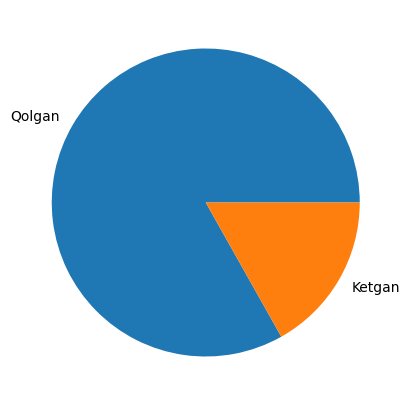

In [223]:
plt.figure(figsize=(5,5))
plt.pie(churn_rate, labels=['Qolgan','Ketgan'])
plt.show()

# plt.pie yordamida yumaloq diagramma qilishimiz mumkin

## Bazi sonli ustunlarni tahlil qilamiz

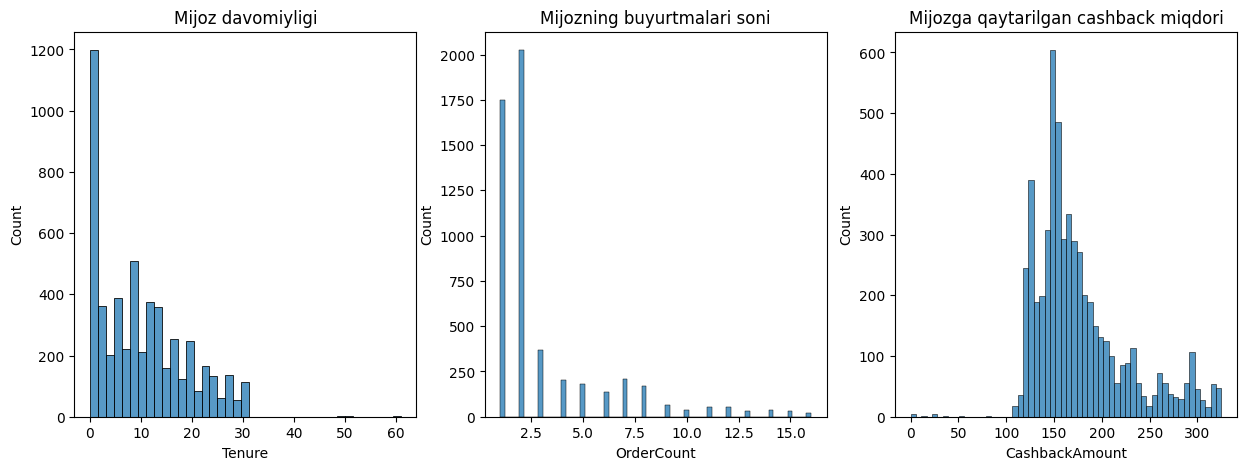

In [224]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

# Tenure
sns.histplot(x="Tenure", data=df, ax=axes[0])
axes[0].set_title("Mijoz davomiyligi")

# OrderCount
sns.histplot(x="OrderCount", data=df, ax=axes[1])
axes[1].set_title("Mijozning buyurtmalari soni")

# Cashback
sns.histplot(x="CashbackAmount", data=df, ax=axes[2])
axes[2].set_title("Mijozga qaytarilgan cashback miqdori")
plt.show()

# Tenure, OrderCount, CashbackAmount bu 3 ta ustun histplot yordamida chiqrildi

## Kategoriyali ustunlarni tahlil qilamiz

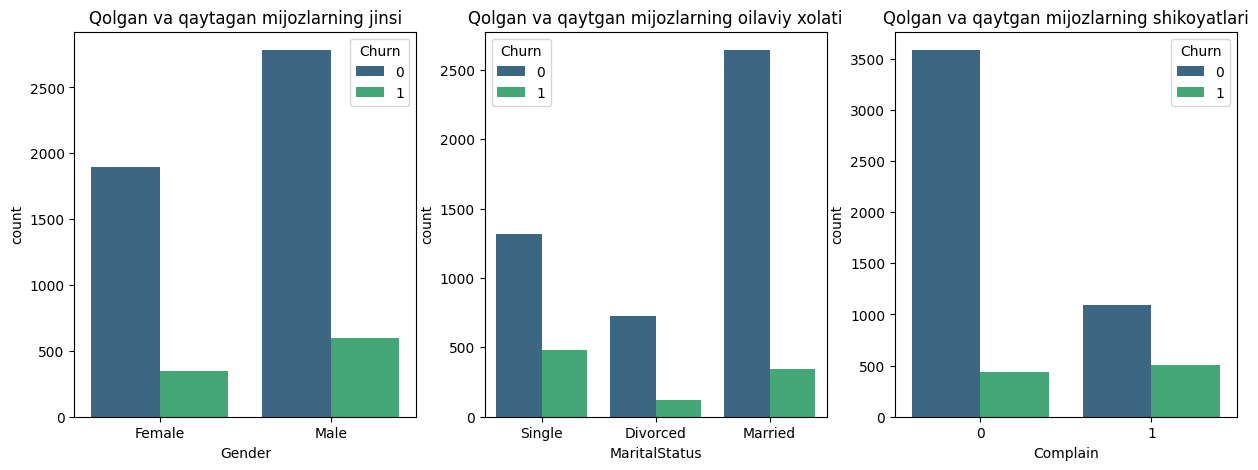

In [225]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.countplot(x='Gender', hue="Churn", palette="viridis", data=df, ax=axes[0])
axes[0].set_title("Qolgan va qaytagan mijozlarning jinsi")

sns.countplot(x='MaritalStatus', hue="Churn", palette="viridis", data=df, ax=axes[1])
axes[1].set_title("Qolgan va qaytgan mijozlarning oilaviy xolati")

sns.countplot(x="Complain", hue='Churn', palette="viridis", data=df, ax=axes[2])
axes[2].set_title("Qolgan va qaytgan mijozlarning shikoyatlari")

plt.show()

# Gender, MaritalStatus, Complain bu 3 df db dagi ustunlar uchun countplot chiqarildi

In [226]:
df.corrwith(df['Churn'], numeric_only=True).abs().sort_values(ascending=False)

# Churn ga nisbatan qolgan sonli ustunlarning correlyasiyasi tekshirildi

,0
Churn,1.000000
Tenure,0.349408
Complain,0.250188
DaySinceLastOrder,0.160757
CashbackAmount,0.154118
NumberOfDeviceRegistered,0.107939
SatisfactionScore,0.105481
CityTier,0.084703
WarehouseToHome,0.076630
NumberOfAddress,0.043931


## Ma'lumotlarga ishlov berish

In [227]:
df.shape

(5630, 20)

In [228]:
# df dagi mavjud bo'lmagan qiymatlar soni
print(f"mavjud bo'lmagan qiymatlar soni: {df.isnull().sum().sum()}")

# mavjud bo'lmagan qatorlar soni
missing_rovs = df[df.isnull().any(axis=1)].shape[0]
print(f"Mavjud bo'lmagan qatorlar soni: {missing_rovs}")

# qatorlar nisbati
print(f"Mavjud bo'lmagan qatorlar %: {np.round(missing_rovs/len(df)*100)}%")

mavjud bo'lmagan qiymatlar soni: 1856
Mavjud bo'lmagan qatorlar soni: 1856
Mavjud bo'lmagan qatorlar %: 33.0%


### Demak ma'lumotlarga qarasak 33 % mavjud emas ekan bu juda ko'p ma'lumotlar yo'qligini va predictni aniqligini pasaytirishini anglatadi

### Biz misol tariqasida faqat korellyatsiyasi yuqori bo'lgan ustunlarni saralab olib ular ustida ishlab ko'ramiz

## Bunday qilishimizga asosiy sabab biz bunda ma'lumotlarni tahlil qilishni emas balki turli yo'llar bilan predict qilish yo'llarini pastda ko'rib chiqamiz.

## Logistic Regression

## Support Vector Machines

## Decision Tree

## Random Forest

## XGBoost

In [229]:
data = df[['Churn','Tenure','Complain','DaySinceLastOrder','CashbackAmount','MaritalStatus','Gender']]

# 20 ta ustundan 7 ta eng kerakli ustunlarni tanlab oldik

In [230]:
data.shape

(5630, 7)

In [231]:
# df dagi mavjud bo'lmagan qiymatlar soni
print(f"mavjud bo'lmagan qiymatlar soni: {data.isnull().sum().sum()}")

# mavjud bo'lmagan qatorlar soni
missing_rovs = data[data.isnull().any(axis=1)].shape[0]
print(f"Mavjud bo'lmagan qatorlar soni: {missing_rovs}")

# qatorlar nisbati
print(f"Mavjud bo'lmagan qatorlar %: {np.round(missing_rovs/len(data)*100)}%")

mavjud bo'lmagan qiymatlar soni: 571
Mavjud bo'lmagan qatorlar soni: 571
Mavjud bo'lmagan qatorlar %: 10.0%


### Demak bunda Churn ustuniga correlyatsiyasi yuqori bo'lgan ustunlarning 10% ida qiymatlar mavjud emas ekan. Biz bu qatorlarni tashlab yuboramiz chunki yuqoridagiga nisbatan kamroq ko'rsatgichni tashkil etadi

In [232]:
data = data.dropna()
data.shape

(5059, 7)

In [233]:
data['Churn'].value_counts()


,count
Churn,
0,4246
1,813


In [234]:
data['Churn'].value_counts()/len(data)

,count
Churn,
0,0.839296
1,0.160704


In [235]:
data

,Churn,Tenure,Complain,DaySinceLastOrder,CashbackAmount,MaritalStatus,Gender
0,1,4.0,1,5.0,159.93,Single,Female
3,1,0.0,0,3.0,134.07,Single,Male
4,1,0.0,0,3.0,129.60,Single,Male
5,1,0.0,1,7.0,139.19,Single,Female
8,1,13.0,1,2.0,126.83,Divorced,Male
...,...,...,...,...,...,...,...
5624,0,1.0,0,1.0,154.66,Single,Female
5625,0,10.0,0,4.0,150.71,Married,Male
5627,0,1.0,1,4.0,186.42,Married,Male
5628,0,23.0,0,9.0,178.90,Married,Male


In [236]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5059 entries, 0 to 5629
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Churn              5059 non-null   int64  
 1   Tenure             5059 non-null   float64
 2   Complain           5059 non-null   int64  
 3   DaySinceLastOrder  5059 non-null   float64
 4   CashbackAmount     5059 non-null   float64
 5   MaritalStatus      5059 non-null   object 
 6   Gender             5059 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 316.2+ KB


# **ML ga tayyorgarlik**

In [237]:
# Matnli ustunlarni True False ga o'tkazamiz qismlarga bo'lgan holda
encoded = pd.get_dummies(data)
encoded.head()
# kod qatori pandas kutubxonasidagi get_dummies funksiyasidan foydalanib, kategorik (matnli) ustunlarni raqamli
# formatga o'tkazadi. Bu jarayon "One-Hot Encoding" deb ataladi. Ya'ni, har bir noyob kategorik qiymat uchun yangi
# ustun yaratiladi va agar qatordagi qiymat ushbu kategoriyaga tegishli bo'lsa, ustunning qiymati 1, aks holda 0 bo'ladi.
# Bu mashinaviy o'rganish modellariga kategorik ma'lumotlarni qayta ishlashga yordam beradi.

,Churn,Tenure,Complain,DaySinceLastOrder,CashbackAmount,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Gender_Female,Gender_Male
0,1,4.0,1,5.0,159.93,False,False,True,True,False
3,1,0.0,0,3.0,134.07,False,False,True,False,True
4,1,0.0,0,3.0,129.60,False,False,True,False,True
5,1,0.0,1,7.0,139.19,False,False,True,True,False
8,1,13.0,1,2.0,126.83,True,False,False,False,True


In [238]:
for col in encoded.select_dtypes(include='bool').columns:
    encoded[col] = encoded[col].astype(int)

encoded.head()

# yuqoridagi True = 1 ga, False = 0 qilib o'zgartirdik bu metod yordamida

,Churn,Tenure,Complain,DaySinceLastOrder,CashbackAmount,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Gender_Female,Gender_Male
0,1,4.0,1,5.0,159.93,0,0,1,1,0
3,1,0.0,0,3.0,134.07,0,0,1,0,1
4,1,0.0,0,3.0,129.60,0,0,1,0,1
5,1,0.0,1,7.0,139.19,0,0,1,1,0
8,1,13.0,1,2.0,126.83,1,0,0,0,1


## X va y ga ajratib olamiz

In [239]:
X = encoded.drop("Churn", axis=1)
y = encoded['Churn']

In [240]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [241]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

# **ML**

# Logistic Regression

              precision    recall  f1-score   support

           0       0.89      0.98      0.93       849
           1       0.75      0.38      0.50       163

    accuracy                           0.88      1012
   macro avg       0.82      0.68      0.72      1012
weighted avg       0.87      0.88      0.86      1012


Model aniqligi: 0.8794466403162056




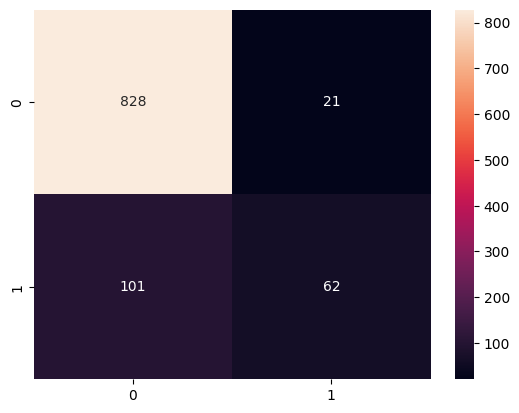

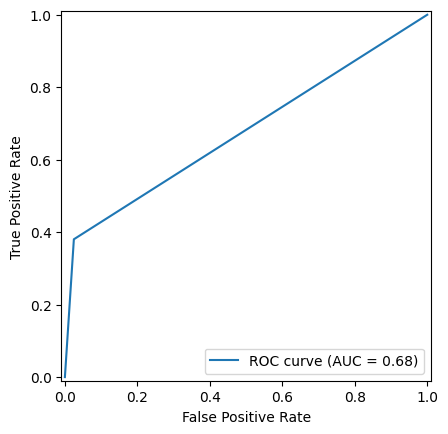

In [242]:
# Modelni yaratamiz (training)
LR_model = LogisticRegression()
LR_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = LR_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))
# precision    recall  f1-score   support bular bo'yicha aniqligini chiqaradi
print("\nModel aniqligi:", metrics.accuracy_score(y_test,y_pred))
print("\n")
# Modelni umumiy aniqligi aniqlandi yani 87%

# confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='g')
plt.show()
# Confusion matrixda 0 yani mijoz qoladi degani va umumiy 849 tadan 21 tasi xato chiqdi
# 1 yani mijoz ketib qoladi degani bunda 163 tadan 101 ta xato chiqdi bu juda yomon ko'rsatgich
# Shuning uchun ham 1 qatori recall va f1-score 38 va 50 % lik kam natijani chiqarayabdi

# ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

# fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred): Bu qator ROC egri chizig'ini chizish uchun zarur
# bo'lgan False Positive Rate (FPR), True Positive Rate (TPR) va **chegara qiymatlari (thresholds)**ni hisoblaydi.
# Bu orqali modelning turli tasnif chegaralarida qanchalik yaxshi ishlaganini ko'rish mumkin.
# roc_auc = metrics.auc(fpr, tpr): Bu ROC egri chizig'i ostidagi maydon (Area Under the Curve - AUC) qiymatini hisoblaydi.
# AUC modelning umumiy ish faoliyatini birgina son bilan ifodalovchi metrikadir. Qiymat 1 ga yaqin bo'lsa, model shuncha yaxshi.
# display = metrics.RocCurveDisplay(...): Bu kod qatori ROC egri chizig'ini vizuallashtirish uchun maxsus obyekt yaratadi.
# Unga yuqorida hisoblangan FPR, TPR va AUC qiymatlari beriladi.
# display.plot(): Bu obyektni ishga tushirib, ROC egri chizig'ini grafik ko'rinishida chiqaradi.
# Bu grafik modelning tasniflash qobiliyatini vizual tarzda tahlil qilish imkonini beradi.


# Support Vector Machines

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       849
           1       0.67      0.31      0.42       163

    accuracy                           0.86      1012
   macro avg       0.77      0.64      0.67      1012
weighted avg       0.85      0.86      0.84      1012

Model aniqligi: 0.8636363636363636


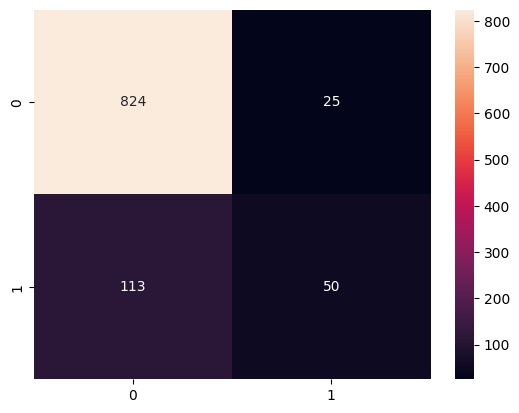

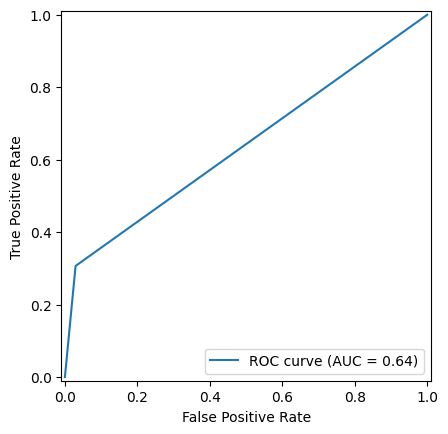

In [243]:
# Huddi yuqoridagi natijalar Support Vector Machines yordamida bajarildi

# Modelni yaratamiz (training)
svc_model = SVC()
svc_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = svc_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

# confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='g')
plt.show()

# ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

# Decision Tree

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       849
           1       0.84      0.90      0.87       163

    accuracy                           0.96      1012
   macro avg       0.91      0.93      0.92      1012
weighted avg       0.96      0.96      0.96      1012

Model aniqligi: 0.9555335968379447


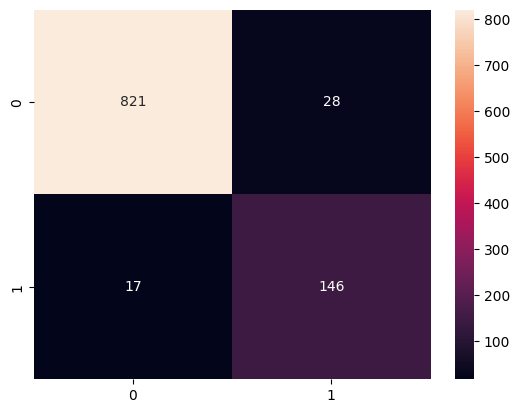

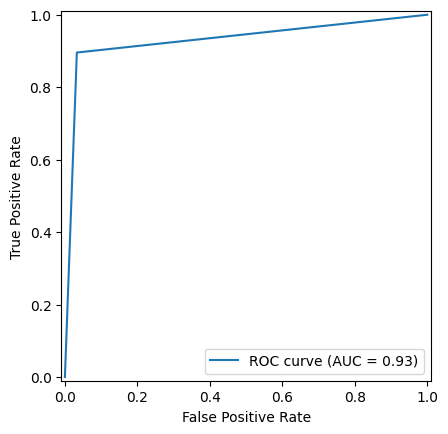

In [244]:
# Huddi yuqoridagi natijalar Decision Tree yordamida bajarildi

# Modelni yaratamiz (training)
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = tree_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

# confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='g')
plt.show()

# ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

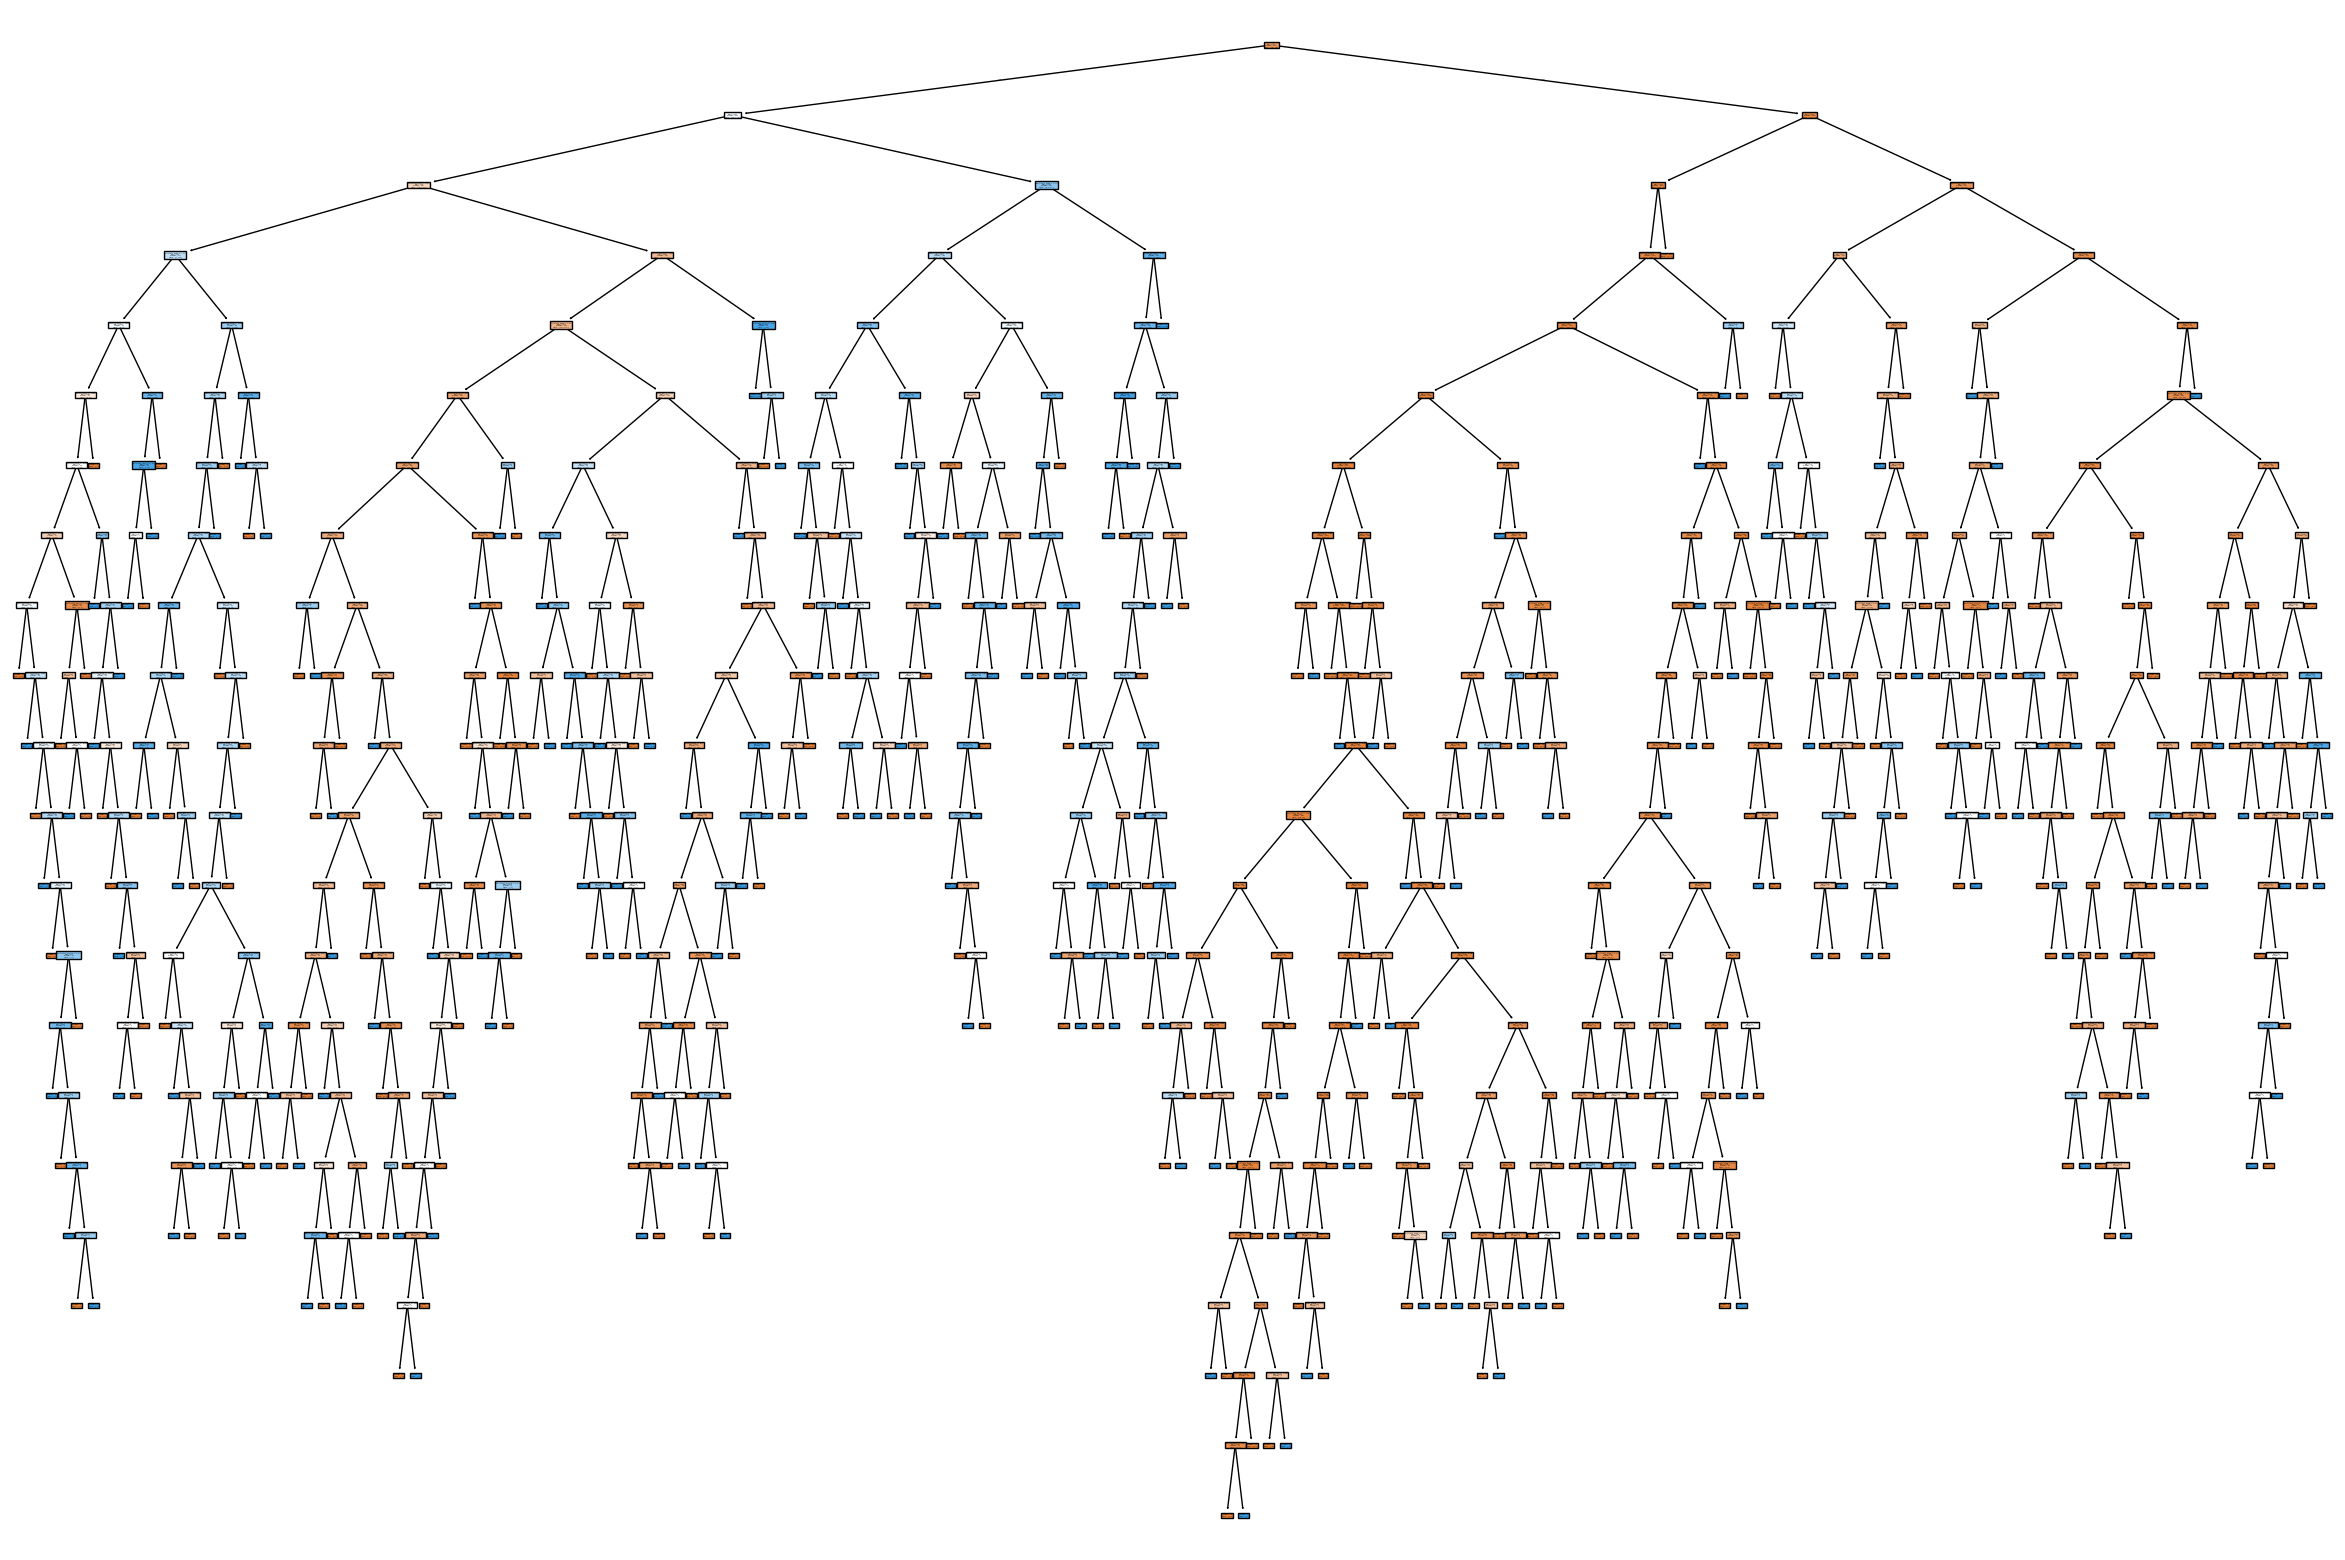

In [245]:
cols = encoded.drop("Churn", axis=1).columns
#  Bu qator encoded nomli ma'lumotlar to'plamidan (DataFrame) "Churn" ustunidan tashqari barcha ustunlarning
# nomlarini olib, cols nomli o'zgaruvchiga saqlaydi. Buni keyinchalik Decision Tree vizualizatsiyasida ustun nomlari sifatida ishlatamiz.
plt.figure(figsize=(30,20))
# parametri grafikning o'lchamini belgilaydi, ya'ni eni 30 dyuym, bo'yi 20 dyuym bo'ladi.
plot_tree(tree_model, feature_names=cols, filled=True)
# Bu qator Decision Tree modelini grafik ko'rinishida tasvirlaydi. Argumentlari quyidagilarni anglatadi:
# tree_model: Oldin o'qitilgan (train qilingan) Decision Tree modelingiz.
# feature_names=cols: Grafikka chiqariladigan ustunlar nomlarini cols o'zgaruvchisidan oladi.
# Bu har bir tugundagi qarorlar qaysi ustunga asoslanganini tushunishga yordam beradi.
# filled=True: Tugunlarni (node) asosiy sinfga qarab rangli qilib ko'rsatadi, bu esa modelning qaror qabul qilish
# jarayonini vizual tarzda tushunishni osonlashtiradi.
plt.show()
# plt.show(): Bu qator yaratilgan Decision Tree grafigini ekranda ko'rsatadi.


### Bundan ko'rishimiz mumkinki decision tree modelimiz juda tarvaqaylab ketdi

### Buni biz hyperparametrlar yordamida nazorat qilishimiz mumkin yani max_depth dan foydalanamiz yani bunga shoxlarini sonini berishimiz mumkin, ammo bunda aniqlik darajasi nisbatan pastroq chiqadi

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       849
           1       0.75      0.52      0.61       163

    accuracy                           0.89      1012
   macro avg       0.83      0.74      0.77      1012
weighted avg       0.89      0.89      0.89      1012

Model aniqligi: 0.8942687747035574


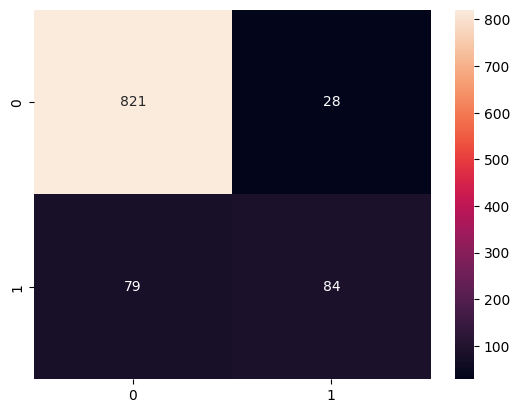

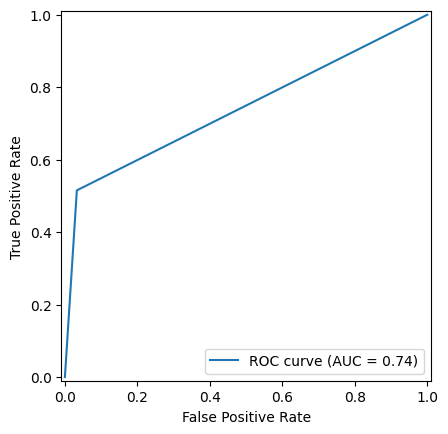

In [246]:
# Modelni yaratamiz (training)
tree_model = DecisionTreeClassifier(max_depth=5)
tree_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = tree_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

# confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='g')
plt.show()

# ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

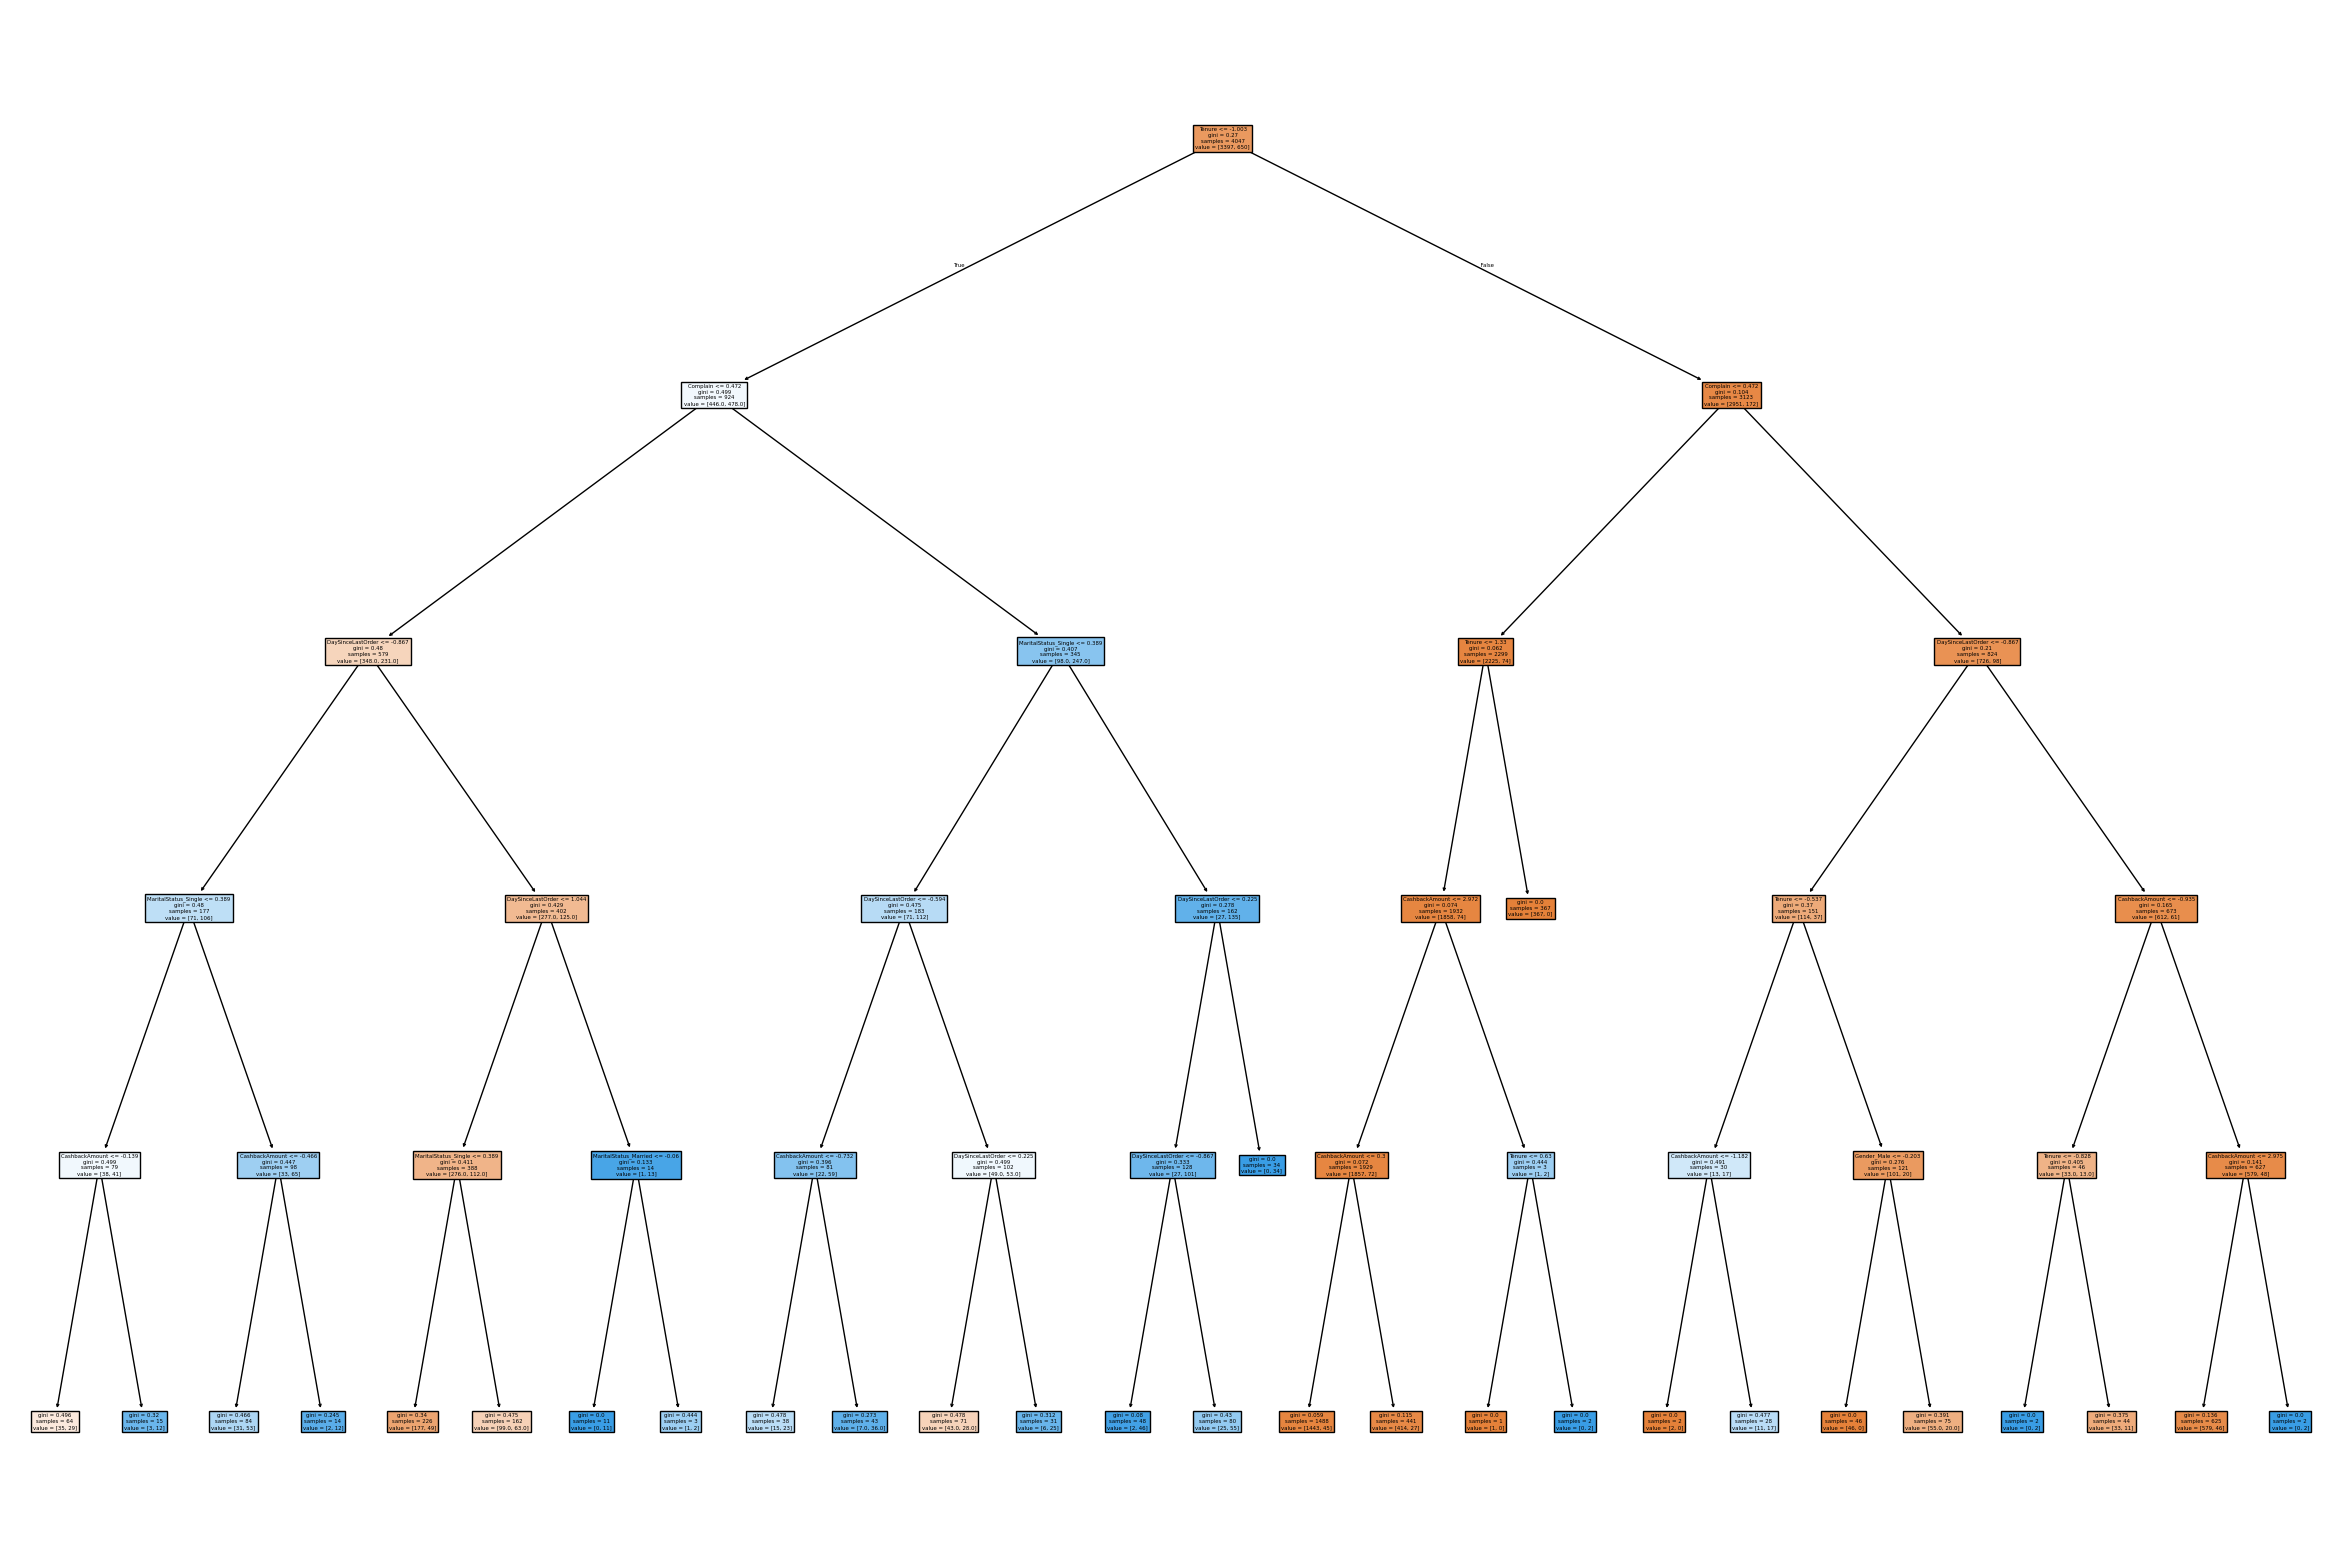

In [247]:
cols = encoded.drop("Churn", axis=1).columns
plt.figure(figsize=(30,20))
plot_tree(tree_model, feature_names=cols, filled=True)
plt.show()

# Bunda yuqorida max_depth=5 qilganimiz uchun aniqligi pastroq chiqdi dastlabkiga nisbatan va daraxt ham kichikroq chiqdi
# Nima uchun bunday daraxt kattaligini kichiraytirib aniqligini pasaytirganimiz sababi train qilish jarayoni sekin bo'ladi

# Eng yaxshi k ni topish

# for yordamida

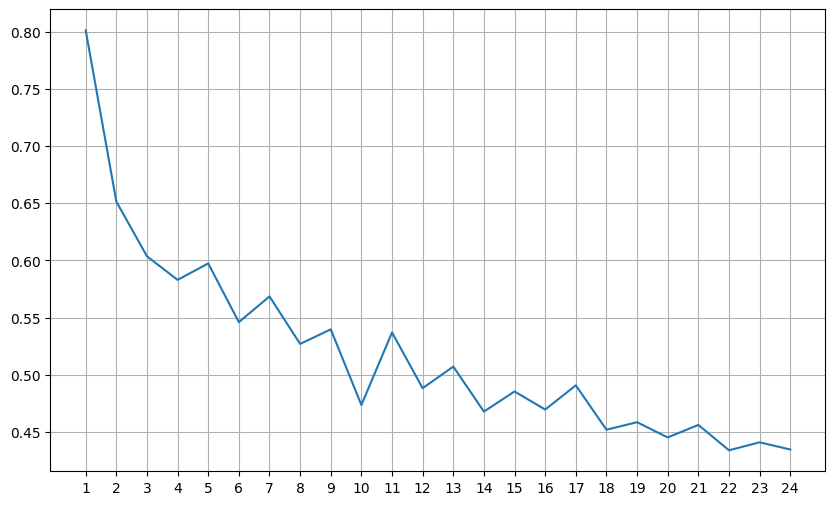

In [248]:
# from sklearn.metrics import f1_score
# from sklearn.neighbors import KNeighborsClassifier

f1 = []
for k in range(1,25):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_predict = knn.predict(X_test)
    f1.append(f1_score(y_test, y_predict))

plt.figure(figsize=(10,6))
plt.plot(range(1,25), f1)
plt.xticks(range(1,25))
plt.grid()
plt.show()

# Grid Search yordamida

In [249]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': np.arange(1, 25)}
knn_gscv = GridSearchCV(knn, param_grid, cv=5)
knn_gscv.fit(X, y)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=24),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [250]:
knn_gscv.cv_results_['rank_test_score']

array([ 1,  2,  5,  3,  4,  6,  7,  8,  9, 19, 11, 14, 12, 13,  9, 17, 16,
       21, 15, 22, 23, 18, 20, 24], dtype=int32)

In [251]:
knn_gscv.best_params_

{'n_neighbors': np.int64(1)}

In [252]:
knn_gscv.best_score_

np.float64(0.9509799322081607)

### yuqorida eng yaxshi k qiymatlarini aniqladik ammo pastda biz ularni bermagan holda bajaramiz chunki max_depth siz ham yaxshi natija chiqmoqda

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       849
           1       0.84      0.89      0.86       163

    accuracy                           0.95      1012
   macro avg       0.91      0.93      0.92      1012
weighted avg       0.96      0.95      0.96      1012

Model aniqligi: 0.9545454545454546


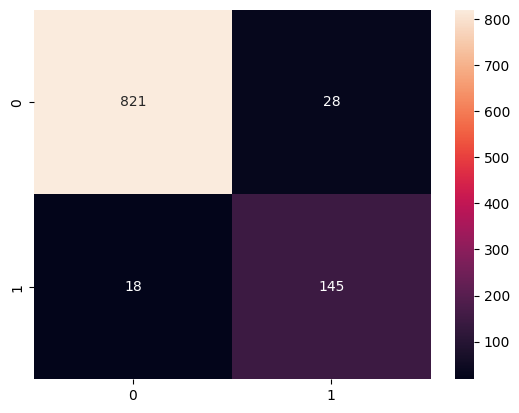

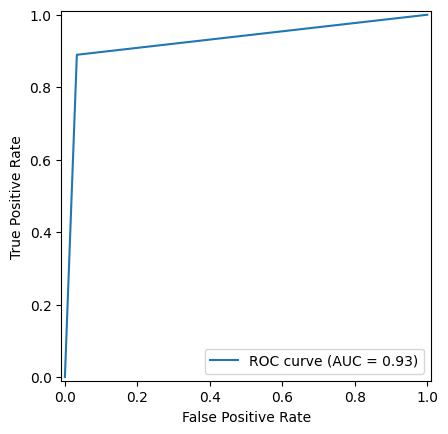

In [253]:
# Modelni yaratamiz (training)
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = tree_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

# confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='g')
plt.show()

# ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

# Random Forest

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       849
           1       0.85      0.79      0.82       163

    accuracy                           0.94      1012
   macro avg       0.91      0.88      0.89      1012
weighted avg       0.94      0.94      0.94      1012

Model aniqligi: 0.9436758893280632


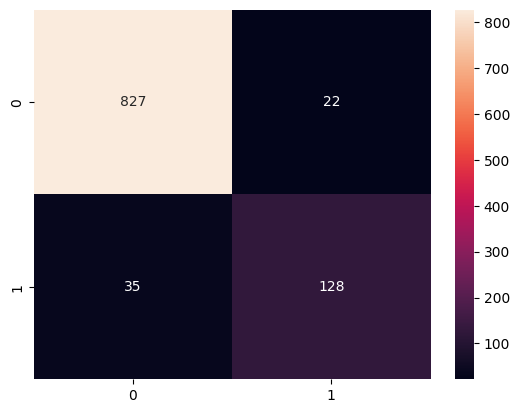

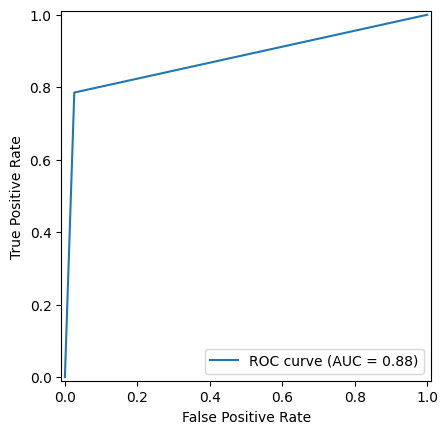

In [254]:
# Modelni yaratamiz (training)
RF_model = RandomForestClassifier(n_estimators=9)
RF_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = RF_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

# confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='g')
plt.show()

# ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

# XGBoost

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       849
           1       0.87      0.77      0.82       163

    accuracy                           0.94      1012
   macro avg       0.91      0.88      0.89      1012
weighted avg       0.94      0.94      0.94      1012

Model aniqligi: 0.9446640316205533


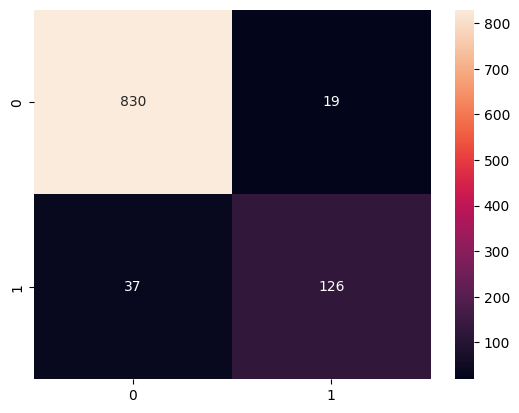

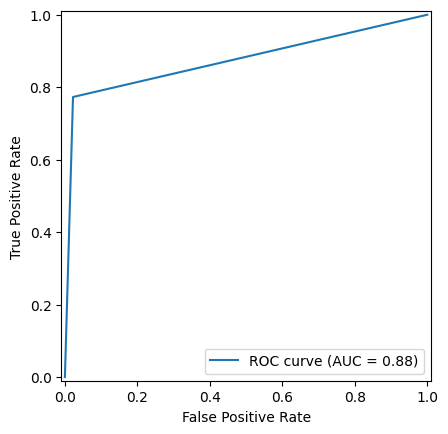

In [255]:
# Modelni yaratamiz (training)
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = xgb_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

# confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='g')
plt.show()

# ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

## Biz yuqorida 5 xil usul bilan predict qildik va eng yaxshi natija
## **Decision Tree** da yani 95% bilan chiqdi